## Lab 7: Phân cụm K-means

### 1. Bài toán: Phân cụm dữ liệu bằng giải thuật Kmeans (Unsupervised Learning)

#### Mục tiêu: 
- Xây dựng mô hình K-means sử dụng thư viện sklearn.
- Áp dụng mô hình để giải quyết một bài toán thực tế (nén ảnh).
- Nắm được cách tinh chỉnh tham số và đánh giá chất lượng mô hình.

#### Dữ liệu:
- Đối với bài toán mô phỏng Kmeans: Sử dụng hàm sinh dữ liệu tự động của sklearn (Sinh ra các điểm ngẫu nhiên theo phân phối Gauss). Mỗi điểm dữ liệu là một điểm trên mặt phẳng Oxy.
- Đối với bài toán nén ảnh: Ảnh flower.jpg (Hình ảnh về một bông hoa).

#### Mô hình hóa bài toán: Bài toán phân cụm
- Đầu vào: N vector D chiều, tương ứng với N điểm dữ liệu với D thuộc tính trong không gian.
- Đầu ra: Các tâm cụm và chỉ số cụm của mỗi điểm dữ liệu đã cho ban đầu.

### 2. Các bước thực hiện

#### 2.1. Các thư viện sử dụng

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

#### 2.2. Bài toán 1: Mô phỏng Kmeans với dữ liệu tự sinh

2.2.1. Chuẩn bị dữ liệu
- Sinh dữ liệu ngẫu nhiên n_samples = 100 tương ứng với 100 điểm dữ liệu.
- Mỗi điểm dữ liệu có 2 chiều (D = 2)

In [ ]:
n_samples = 100
random_state = 170
center_points = [[1,1], [-1,-1], [1,-1]]
# center_points = 3 # Tâm cụm được chọn ngẫu nhiên
X, y = make_blobs(n_samples=n_samples, random_state=random_state, centers=center_points, cluster_std=0.6)
print("Số chiều dữ liệu: ", X.shape, y.shape)
print("5 điểm dữ liệu đầu tiên: \n", X[:5])

Số chiều dữ liệu:  (100, 2) (100,)
5 điểm dữ liệu đầu tiên: 
 [[ 1.26241305  0.94872541]
 [-0.39743873 -1.18567406]
 [ 1.35081331  0.48041993]
 [ 1.21219555  0.98929291]
 [-0.75344338 -1.09784774]]


In [3]:
set(y) # Kiểm tra nhanh số lượng nhãn khác nhau

{0, 1, 2}

Vẽ các điểm dữ liệu sử dụng matplotlib

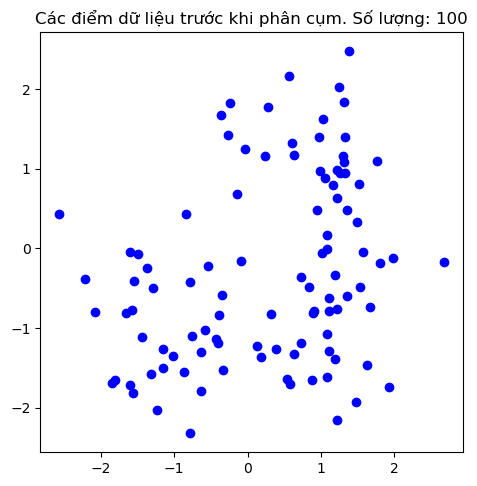

In [4]:
plt.figure(figsize=(12, 12))
plt.subplot(221)
plt.scatter(X[:, 0], X[:, 1], c='blue')
plt.title(f"Các điểm dữ liệu trước khi phân cụm. Số lượng: {n_samples}")
plt.show()

2.2.2. Xây dựng giải thuật Kmeans

In [5]:
k_cluster = 3
kmean_model = KMeans(n_clusters=k_cluster, random_state=random_state)
kmean_model.fit(X)
centers = np.array(kmean_model.cluster_centers_) # cluster_centers_: là thuộc tính lưu trữ các tâm cụm sau khi training
print(f"Tâm cụm sau khi training ({k_cluster} tâm): \n", centers)

Tâm cụm sau khi training (3 tâm): 
 [[ 0.88823619  1.19442485]
 [-1.13949326 -0.97100768]
 [ 1.11177838 -0.94555162]]


d:\APP\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
d:\APP\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


2.2.3. Đánh giá mô hình
- Kiểm tra các điểm dữ liệu thuộc vào cụm nào
- Vẽ biểu đồ hiển thị kết quả, trong đó các điểm thuộc các cụm khác nhau sẽ có màu khác nhau.

Kết quả dự đoán cho 5 mẫu dữ liệu đầu tiên trong tập data: 

[0 1 0 0 1]


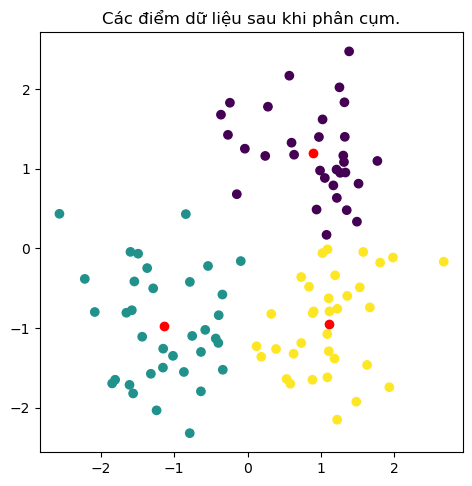

In [6]:
y_pred = kmean_model.predict(X)
print("Kết quả dự đoán cho 5 mẫu dữ liệu đầu tiên trong tập data: \n")
print(y_pred[:5])
plt.figure(figsize=(12, 12))
plt.subplot(222)
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.scatter(centers[:, 0], centers[:, 1], c='red')
plt.title("Các điểm dữ liệu sau khi phân cụm.")
plt.show()

2.2.4. Bài tập 1

Yêu cầu: Thử nghiệm trường hợp dữ liệu sinh ra chỉ có 2 cụm nhưng xây dựng Kmeans với các tham số K = {3, 4, 5} cụm.
- Viết code sinh dữ liệu tương tự như Bài toán 1.
- Xây dựng mô hình với số cụm lần lượt = 3, 4, 5.

Gợi ý: Thay đổi tham số số cụm khi xây dựng giải thuật Kmeans.

Kết quả: Phải hiển thị được hình ảnh thể hiện đúng số tâm cụm và phân bố cụm.

#### 2.3. Bài toán 1: Ứng dụng Kmeans để nén ảnh

Đặt vấn đề:
 + Muốn xây dựng một hệ thống nén dữ liệu hình ảnh.
 + Có thể tùy chỉnh được độ sắc nét, giảm kích thước bộ nhớ, nhưng không làm sai lệch quá nhiều so với ảnh gốc dưới cảm nhận màu sắc tổng thể.

Giải pháp:
 + Áp dụng giải thuật K-Means để tự động phân cụm các điểm ảnh dựa trên đặc trưng màu sắc.
 + Giới hạn số lượng màu của ảnh bằng cách xác định trước số cụm k, từ đó giảm kích thước dữ liệu ảnh.
 + Mỗi điểm ảnh sau phân cụm sẽ được gán vào cụm gần nhất và nhận giá trị màu bằng màu của tâm cụm tương ứng.

2.3.1. Thư viện cần thiết

In [7]:
from skimage import io 
import matplotlib.image as image
from IPython.display import Image, display # Hiển thị hình ảnh

2.3.2. Đọc dữ liệu hình ảnh
- Mỗi điểm ảnh là một mẫu quan sát.
- Phân cụm tập dữ liệu (tập các điểm ảnh) về K cụm

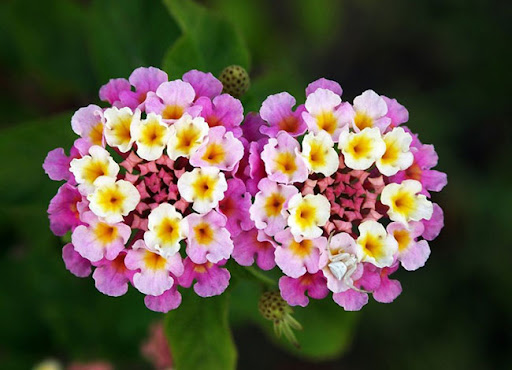

In [ ]:
path_img = 'flower.jpg'
Image(path_img, width=250, unconfined=True)

In [9]:
img = io.imread(path_img)
print("Dữ liệu ảnh trước khi reshape:", img.shape)
image_shape = img.shape
data_img = (img / 255.0).reshape(-1,img.shape[2]) # Chuyển ma trận 370x512x3 về mảng 2 chiều, giữ lại chiều shape[2]
print("Số chiều của dữ liệu hình ảnh: ", data_img.shape)
print("Tổng số điểm ảnh là: ", data_img.shape[0])
print("Mỗi điểm ảnh có số chiều = ", data_img.shape[1])

Dữ liệu ảnh trước khi reshape: (370, 512, 3)
Số chiều của dữ liệu hình ảnh:  (189440, 3)
Tổng số điểm ảnh là:  189440
Mỗi điểm ảnh có số chiều =  3


In [11]:
a = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]], [[13, 14, 15], [16, 17, 18]]])
a.shape

(3, 2, 3)

In [12]:
a.reshape(-1, 3)

array([[ 1,  2,  3],
       [ 4,  5,  6],
       [ 7,  8,  9],
       [10, 11, 12],
       [13, 14, 15],
       [16, 17, 18]])

2.3.3. Xây dựng mô hình Kmeans để nén ảnh
- Số lượng cụm chính là số lượng màu ta giữ lại.
- Số lượng cụm càng nhỏ thì kích thước ảnh cho ra càng nhỏ.

In [10]:
n_color = 10
kmean_model = KMeans(n_clusters=n_color)
kmean_model.fit(data_img)

d:\APP\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=10)

In [11]:
# Hiển thị một số thông tin đã học của mô hình
print("Số chiều của tâm cụm: ", kmean_model.cluster_centers_.shape)
print(kmean_model.cluster_centers_)
print(kmean_model.labels_[0:20])

Số chiều của tâm cụm:  (10, 3)
[[0.11034376 0.19790191 0.05520751]
 [0.93147724 0.88852706 0.88920411]
 [0.75328422 0.40880779 0.68834234]
 [0.88290542 0.80069997 0.4799182 ]
 [0.48213958 0.18134024 0.19950918]
 [0.65955138 0.25545683 0.4772205 ]
 [0.85399893 0.67535738 0.82447895]
 [0.0693885  0.10274371 0.04727942]
 [0.8580159  0.63584007 0.06634373]
 [0.20045142 0.30909276 0.07052263]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [12]:
# k_mean_model.labels_: chứa nhãn của tất cả các điểm ảnh
# k_mean_model.cluster_centers_: chứa các tâm cụm.

new_img = kmean_model.cluster_centers_[kmean_model.labels_]
print(new_img.shape)
# Chuẩn hoá lại kích thước ảnh theo chiều dài, rộng ban đầu
new_img = np.reshape(new_img, image_shape)
print(new_img.shape)
image.imsave('new_img.png', new_img)

(189440, 3)
(370, 512, 3)


In [13]:
# Hiển thị kích thước hình ảnh trước và sau khi nén
import os
print('Kích thước của ảnh nén: ' + str(os.path.getsize('new_img.png')) + ' KB')
print('Kích thước của ảnh gốc: ' + str(os.path.getsize(path_img)) + 'KB')

Kích thước của ảnh nén: 44756 KB
Kích thước của ảnh gốc: 61812KB


Ảnh nén: 


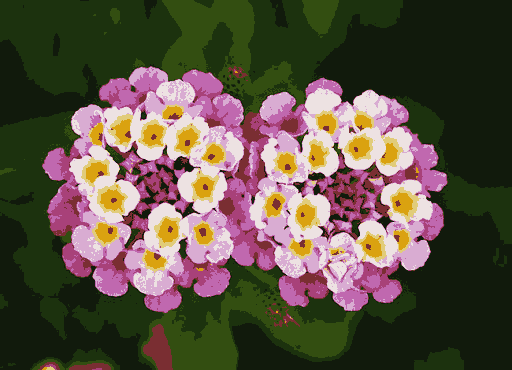

Ảnh gốc: 


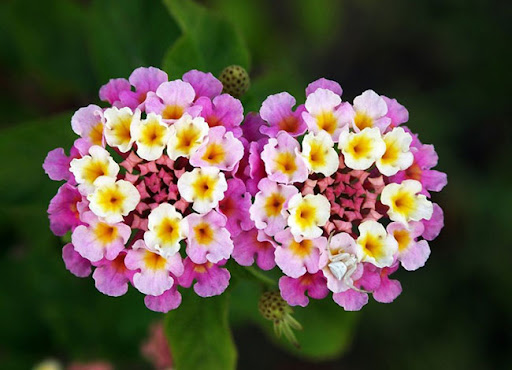

In [ ]:
# Save image
print('Ảnh nén: ')
display(Image('new_img.png', width=250, unconfined=True))
print("Ảnh gốc: ")
display(Image(path_img, width=250, unconfined=True))

2.3.5. Bài tập 2

Yêu cầu: Nén ảnh trên thành ảnh có số màu < 5 và kiểm tra kết quả hiển thị.

Gợi ý: Thay đổi tham số "số cụm" khi xây dựng Kmeans.

#### 2.4. Bài tập bổ sung

Làm sao để biết số cụm bằng bao nhiêu là phù hợp với dữ liệu?

- Cách 1: Sử dụng hệ số Silhouette để tìm ra số cụm tối ưu trong một tập các cụm có thể có.
- Cách 2: Sử dụng tiêu chuẩn inertia để đánh giá. Inertia được tính bằng tổng bình phương khoảng cách của các mẫu đến trung tâm cụm gần nhất của chúng. Một mô hình tốt là mô hình có chỉ số inertia nhỏ và số lượng cụm bé. Vấn đề: số cụm càng lớn thì inertia càng nhỏ -> Chọn số cụm hợp lý bằng cách: chọn điểm mà độ giảm inertia bắt đầu chậm lại (elbow).


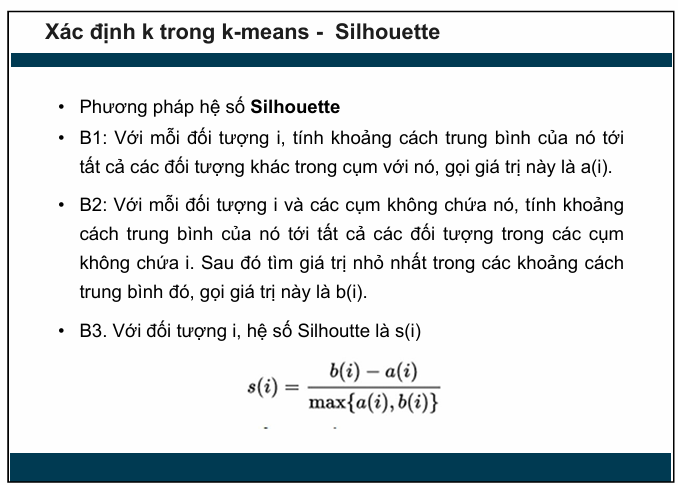

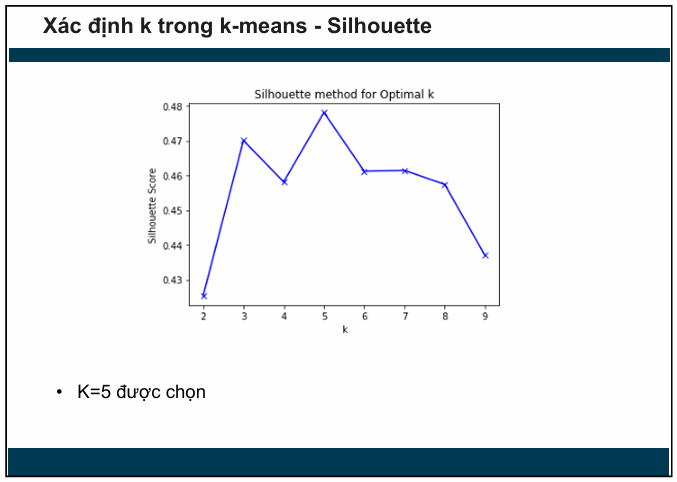

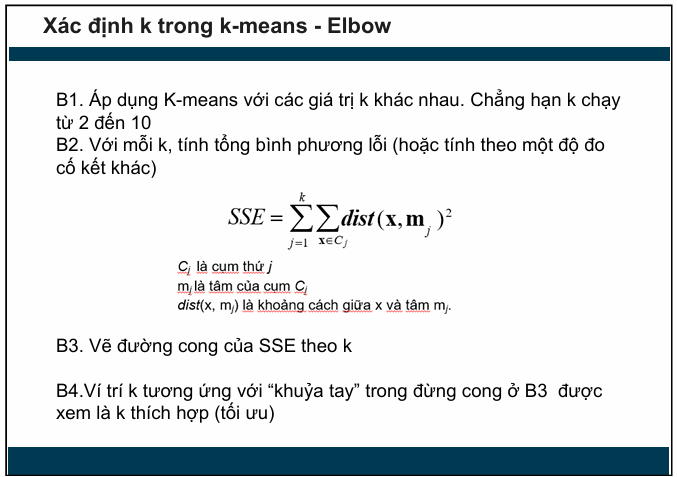

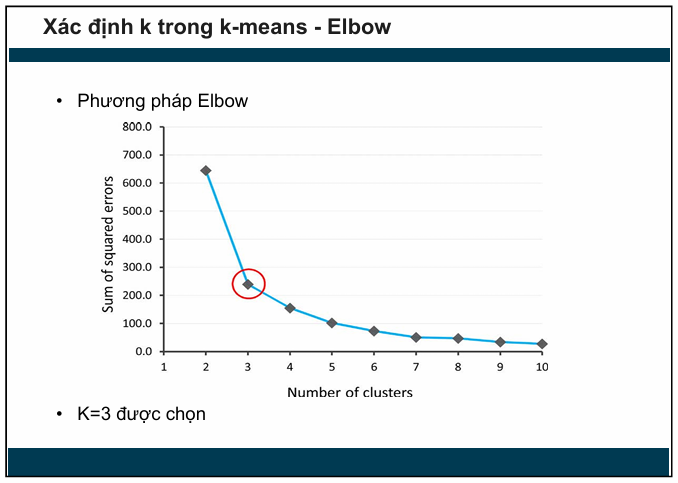

Yêu cầu:
- Viết code tìm số cụm tối ưu cho mô hình của các điểm dữ liệu ở Bài toán 1 dựa trên chỉ số Silhouette (Đánh giá mức độ phân tách cụm) và Inertia (Tổng khoảng cách bình phương tới tâm cụm).

Các bước thực hiện:
- Thiết lập số cụm K chạy từ 1 đến 10.
- Với mỗi K:
    + Huấn luyện mô hình Kmeans
    + Tính toán: Silhouette Score và Inertia
- Vẽ biểu đồ thể hiện sự tương quan giữa:
    + Giá trị Silhouette và số cụm; 
    + Inertia và số cụm.
- Giá trị K tối ưu là vị trí:
    + Silhouette Score đạt cực đại
    + Điểm Elbow trên đồ thị Inertia.